In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
t2012 = pd.read_csv(
    "Tabela5-sem_emprego_2012.csv", sep=";", decimal=",", encoding="utf-8-sig"
)
t2026 = pd.read_csv(
    "Tabela5-sem_emprego_2026.csv", sep=";", decimal=",", encoding="utf-8-sig"
)

t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})
t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})

comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
print("Tabelas 5 unidas:")
print(comp.head())
print(comp.shape)

Tabelas 5 unidas:
  Sigla  Código    Estado  homens_2012  mulheres_2012  homens_2026  \
0    AC      12      Acre         45.3           54.7         53.2   
1    AL      27   Alagoas         44.7           55.3         50.7   
2    AM      13  Amazonas         47.5           52.5         46.8   
3    AP      16     Amapá         48.1           51.9         51.1   
4    BA      29     Bahia         43.8           56.2         44.7   

   mulheres_2026  
0           46.8  
1           49.3  
2           53.2  
3           48.9  
4           55.3  
(27, 7)


In [7]:
import os
print(os.getcwd())
print(os.listdir())

h:\Python\3° Etapa\Atividade6
['aula6.ipynb', 'atividade_desocupacao.py', 'Tabela 1.1.1.xls', 'Tabela5-sem_emprego_2026.csv', 'Tabela5-sem_emprego_2012.csv']


In [9]:
cuidados = pd.read_excel("Tabela 1.1.1.xls", sheet_name="2022", header=None)

cuidados = cuidados.iloc[8:41, [0, 1]]
cuidados.columns = ["Estado", "Horas_cuidados_domesticos"]

regioes = ["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
cuidados = cuidados[~cuidados["Estado"].isin(regioes)].reset_index(drop=True)
cuidados

,Estado,Horas_cuidados_domesticos
0,Rondônia,17.014162
1,Acre,13.606903
2,Amazonas,16.80729
3,Roraima,13.639257
4,Pará,16.474268
5,Amapá,13.586656
6,Tocantins,15.815781
7,Maranhão,16.669614
8,Piauí,17.960366
9,Ceará,19.499293


In [10]:
comp = comp.merge(cuidados, on="Estado", how="left")
print("\nTabela final cruzada:")
print(comp.head())
print("\nValores faltando após o merge:")
print(comp.isna().sum())


Tabela final cruzada:
  Sigla  Código    Estado  homens_2012  mulheres_2012  homens_2026  \
0    AC      12      Acre         45.3           54.7         53.2   
1    AL      27   Alagoas         44.7           55.3         50.7   
2    AM      13  Amazonas         47.5           52.5         46.8   
3    AP      16     Amapá         48.1           51.9         51.1   
4    BA      29     Bahia         43.8           56.2         44.7   

   mulheres_2026 Horas_cuidados_domesticos  
0           46.8                 13.606903  
1           49.3                 20.217129  
2           53.2                  16.80729  
3           48.9                 13.586656  
4           55.3                 17.849776  

Valores faltando após o merge:
Sigla                        0
Código                       0
Estado                       0
homens_2012                  0
mulheres_2012                0
homens_2026                  0
mulheres_2026                0
Horas_cuidados_domesticos    0
dtype:

In [11]:
ordem = comp.sort_values("Horas_cuidados_domesticos", ascending=False)["Estado"]

longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado", "Horas_cuidados_domesticos"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

print("\nTabela em formato longo:")
print(longo.head())


Tabela em formato longo:
  Sigla  Código    Estado Horas_cuidados_domesticos      Ano  \
0    AC      12      Acre                 13.606903  2012 T1   
1    AL      27   Alagoas                 20.217129  2012 T1   
2    AM      13  Amazonas                  16.80729  2012 T1   
3    AP      16     Amapá                 13.586656  2012 T1   
4    BA      29     Bahia                 17.849776  2012 T1   

   Participacao_mulheres  
0                   54.7  
1                   55.3  
2                   52.5  
3                   51.9  
4                   56.2  


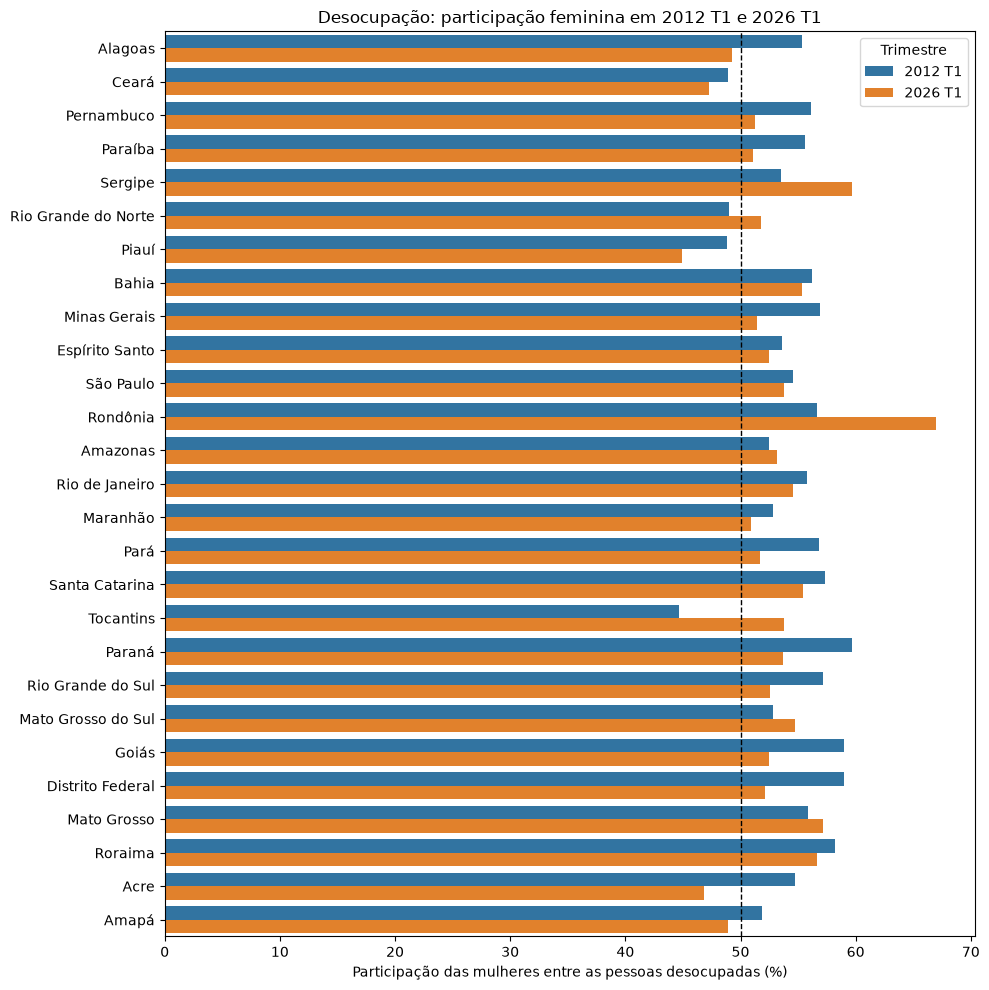

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Trimestre")
fig.tight_layout()
plt.show()